# Michaelis and Menten, worked through StatesAndRates

An enzyme turning substrate into product, written as a graph of states
and solved for everything an experiment on it could measure: the
steady-state rate law, $K_\mathrm{M}$ and $k_\mathrm{cat}$, the
commitment to catalysis, the pre-steady-state transient, single-molecule
turnovers, which step controls the rate, and the concentration at which
the enzyme runs backwards.

Nothing below is a rate law assumed in advance. The mechanism goes in as
a topology plus six rate constants, and every one of those quantities
comes out of it.

Rates are per second, concentrations in $\mu$M, and free energies in
kcal/mol. The numbers are invented but ordinary for a small enzyme.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import statesandrates as sr

plt.rcParams.update(
    {
        "figure.figsize": (5, 3.2),
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 1. The mechanism

Substrate binds, chemistry happens on the enzyme, and product leaves:

$$\mathrm{E} + \mathrm{S}
\;\rightleftharpoons\; \mathrm{ES}
\;\rightleftharpoons\; \mathrm{EP}
\;\rightleftharpoons\; \mathrm{E} + \mathrm{P}$$

| transition | rate | meaning |
| --- | --- | --- |
| E → ES | $k_\mathrm{on}[\mathrm{S}]$ | substrate binding |
| ES → E | $k_\mathrm{off}$ | substrate release |
| ES → EP | $k_\mathrm{chem}$ | the chemical step |
| EP → ES | $k_\mathrm{chem}'$ | its reverse |
| EP → E | $k_\mathrm{rel}$ | product release |
| E → EP | $k_\mathrm{rebind}[\mathrm{P}]$ | product rebinding |

There is no $k_\mathrm{cat}$ in that table, and that is deliberate.
The textbook scheme writes turnover as a single irreversible step
$\mathrm{ES} \to \mathrm{E} + \mathrm{P}$ with rate
$k_\mathrm{cat}$, which bundles two physically separate events —
chemistry and product release — into one arrow, and throws away the
reverse of the chemistry while it is at it. Here they are the three
transitions ES $\rightleftharpoons$ EP $\to$ E, so
$k_\mathrm{cat}$ is not a rate constant of the mechanism at all. It is
a *macroscopic* quantity: the turnover number the graph predicts, which
section 4 recovers by fitting. Neither is $K_\mathrm{M}$ a rate
constant. Both are outputs.

The product state EP is not decoration either. A graph holds one rate
constant per ordered pair of states, so ES cannot return to E by two
different routes at two different rates. Substrate release and turnover
are two different fates, so they need two different destinations, and
giving the product its own state is how to say so.

Written as a `Scheme`, the mechanism carries the names of its rate
constants and no values at all.

In [2]:
MICHAELIS = sr.Scheme(
    {
        ("E", "ES"): "k_on",
        ("ES", "E"): "k_off",
        ("ES", "EP"): "k_chem",
        ("EP", "ES"): "k_chem_rev",
        ("EP", "E"): "k_rel",
        ("E", "EP"): "k_rebind",
    },
    latex={
        "k_on": r"$k_\mathrm{on}[\mathrm{S}]$",
        "k_off": r"$k_\mathrm{off}$",
        "k_chem": r"$k_\mathrm{chem}$",
        "k_chem_rev": r"$k_\mathrm{chem}'$",
        "k_rel": r"$k_\mathrm{rel}$",
        "k_rebind": r"$k_\mathrm{rebind}[\mathrm{P}]$",
    },
)
LAYOUT = {"E": (0.0, 0.0), "ES": (1.0, 0.8), "EP": (2.0, 0.0)}

# Turnover with the product removed as fast as it appears, which is the
# textbook idealization: the same mechanism minus one transition
IRREVERSIBLE = sr.Scheme(
    {
        edge: name
        for edge, name in MICHAELIS.symbols.items()
        if name != "k_rebind"
    },
    latex={
        name: text
        for name, text in MICHAELIS.latex.items()
        if name != "k_rebind"
    },
    states=MICHAELIS.states,
)

print(MICHAELIS, "\nrates to supply:", MICHAELIS.names)

Scheme(states=('E', 'ES', 'EP'), transitions=6) 
rates to supply: ('k_chem', 'k_chem_rev', 'k_off', 'k_on', 'k_rebind', 'k_rel')


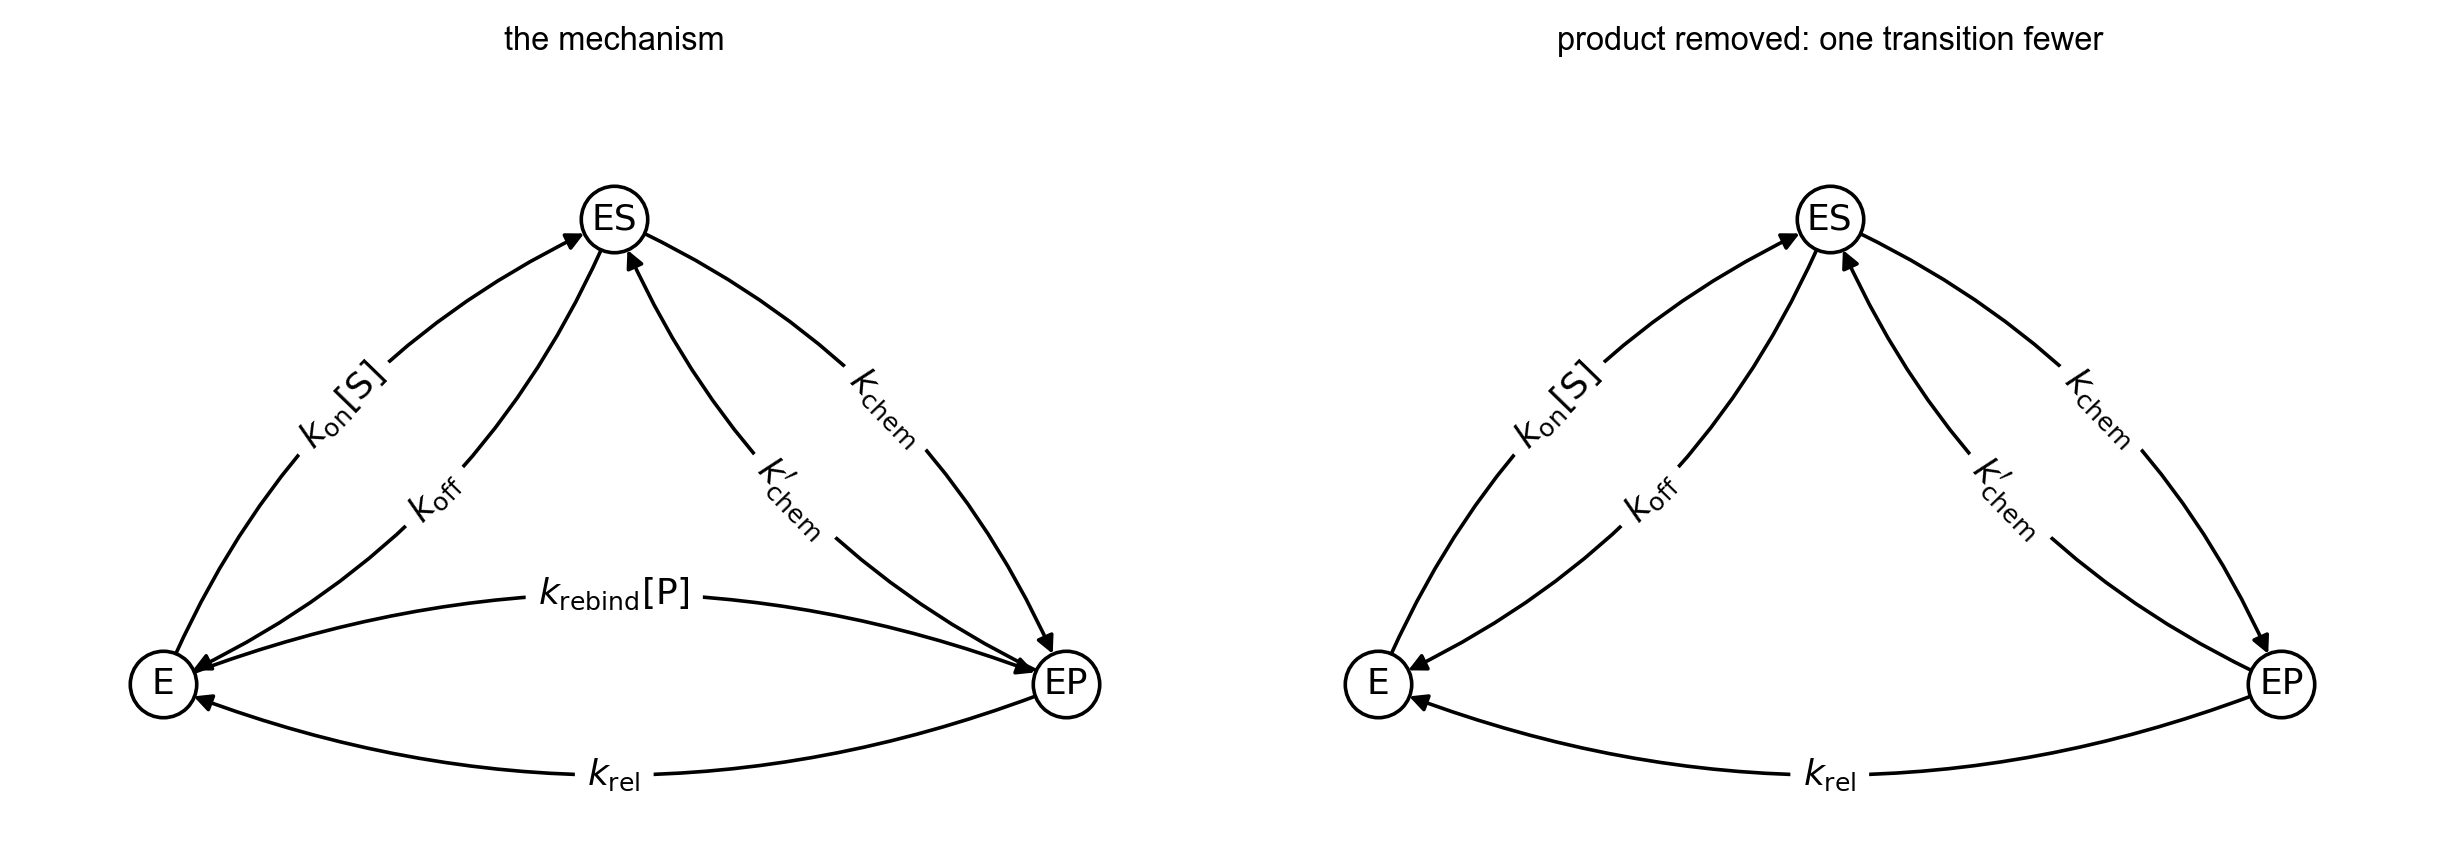

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for ax, scheme, title in zip(
    axes,
    (MICHAELIS, IRREVERSIBLE),
    ("the mechanism", "product removed: one transition fewer"),
):
    sr.state_diagram(scheme, LAYOUT, ax=ax, curvature=0.2)
    ax.set_title(title, fontsize=9)
fig.tight_layout()
plt.show()

## 2. Concentrations, and what "first order" costs

The package is strictly first order: every transition is one molecule
changing state, at a rate that does not depend on how many other
molecules there are. Substrate binding is not like that — it is
bimolecular, second order in E and S.

The standard way out is the one used here. Substrate is in large excess,
so $[\mathrm{S}]$ does not change measurably over a turnover, and the
binding step becomes **pseudo-first-order** with rate constant
$k_\mathrm{on}[\mathrm{S}]$. The concentration is folded into the rate
constant, and a graph is therefore a snapshot at one concentration. To
vary $[\mathrm{S}]$, build a new graph.

That is why the builder below takes concentrations as arguments rather
than the graph taking them as state. Every free energy in this notebook
is likewise a $\Delta G$ at these concentrations, not a standard-state
$\Delta G^\circ$.

In [4]:
RATES = {
    "k_on": 10.0,  # /uM/s, bimolecular
    "k_off": 400.0,  # /s
    "k_chem": 200.0,  # /s
    "k_chem_rev": 5.0,  # /s
    "k_rel": 300.0,  # /s
    "k_rebind": 1.0,  # /uM/s, bimolecular
}


def enzyme(
    substrate: float, product: float | None = None, **overrides: float
) -> sr.Graph:
    """Graph at one substrate and product concentration, in uM.

    Passing no product removes the rebinding transition entirely, which
    is the irreversible idealization rather than a very small rate.
    """
    values = dict(RATES, **overrides)
    values["k_on"] = values["k_on"] * substrate
    if product is None:
        return IRREVERSIBLE.graph(
            {k: v for k, v in values.items() if k != "k_rebind"}
        )
    values["k_rebind"] = values["k_rebind"] * product
    return MICHAELIS.graph(values)


def turnover(graph: sr.Graph) -> float:
    """Products per second per enzyme: the net flux to product."""
    net = sr.fluxes(graph)
    return float(net[graph.index("ES"), graph.index("EP")])


print(enzyme(100.0), "\n")
for source, target in enzyme(100.0).edges:
    graph = enzyme(100.0)
    rate = graph.rates[graph.index(source), graph.index(target)]
    print(f"  {source:>3} -> {target:<3} {rate:9.4g} /s")

Graph(states=('E', 'ES', 'EP'), transitions=5) 

    E -> ES       1000 /s
   ES -> E         400 /s
   ES -> EP        200 /s
   EP -> E         300 /s
   EP -> ES          5 /s


W0910 15:36:30.601059 4564700 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 3. A steady state, not an equilibrium

`equilibrium` solves for the stationary distribution — the occupancies
that stop changing — and that is well defined whether or not the graph
is at thermodynamic equilibrium. A working enzyme is not: it turns over,
and turnover means a net circulation around the cycle
E → ES → EP → E.

Three functions say so in three ways. `is_detailed_balanced` reports
that the Kolmogorov condition fails. `fluxes` gives the net flux through
every transition, which is nonzero and equal all the way round the
cycle, because probability is conserved at each state. And
`cycle_affinity` gives the free energy dissipated per turn: infinite
here, because a transition with no reverse is an infinite driving force.
Removing product as fast as it appears is not a small idealization.

In [5]:
graph = enzyme(100.0)
CYCLE = ["E", "ES", "EP"]
print("occupancies at 100 uM:")
for state, occupancy in zip(graph.states, sr.equilibrium(graph)):
    print(f"  {state:>3} {occupancy:.4f}")
print(f"\ndetailed balanced: {sr.is_detailed_balanced(graph)}")
print(f"affinity of E -> ES -> EP: {sr.cycle_affinity(graph, CYCLE)} kcal/mol")

net = np.asarray(sr.fluxes(graph))
steps = list(zip(CYCLE, CYCLE[1:] + CYCLE[:1]))
print("\nnet flux, /s per enzyme:")
for source, target in steps:
    print(
        f"  {source:>3} -> {target:<3}"
        f" {net[graph.index(source), graph.index(target)]:.4f}"
    )
print(f"conserved at every state: {np.abs(net.sum(axis=1)).max():.2e}")
print(f"antisymmetric: {np.abs(net + net.T).max():.2e}")

occupancies at 100 uM:


    E 0.2649
   ES 0.4440
   EP 0.2911

detailed balanced: False
affinity of E -> ES -> EP: inf kcal/mol

net flux, /s per enzyme:
    E -> ES  87.3362
   ES -> EP  87.3362
   EP -> E   87.3362
conserved at every state: 2.84e-14
antisymmetric: 0.00e+00


## 4. The rate law is not an approximation

The Michaelis-Menten form is usually introduced with a steady-state
*approximation*. For this graph it is not an approximation at all: the
turnover flux is exactly

$$v = \frac{V_\mathrm{max}[\mathrm{S}]}{K_\mathrm{M} + [\mathrm{S}]}$$

because only one rate constant depends on $[\mathrm{S}]$ and the
mechanism is a single cycle, which makes the stationary flux a ratio of
two polynomials, each linear in $[\mathrm{S}]$. Fitting that form to the
computed flux leaves a residual at the level of double precision.

What the fit does *not* give is the textbook expression for
$K_\mathrm{M}$. The two-state reading
$(k_\mathrm{off} + k_\mathrm{chem}) / k_\mathrm{on}$ is 60 $\mu$M
against a true 36, out by two thirds, because it has nowhere to put the
fact that EP can fall back to ES. Reading $k_\mathrm{cat}$ as chemistry
and release in series does better — 120 /s against 118.8 — but is still
an approximation rather than the answer. The graph does not need either
formula.

In [6]:
SUBSTRATE = np.geomspace(0.3, 3000.0, 40)
rate = np.array([turnover(enzyme(s)) for s in SUBSTRATE])

# A Lineweaver-Burk fit: 1/v is linear in 1/[S] if the form is right
design = np.stack([np.ones_like(SUBSTRATE), 1 / SUBSTRATE], axis=1)
(intercept, slope), *_ = np.linalg.lstsq(design, 1 / rate, rcond=None)
VMAX, KM = 1 / intercept, slope / intercept
predicted = VMAX * SUBSTRATE / (KM + SUBSTRATE)

print(f"V_max = {VMAX:.4f} /s      K_M = {KM:.4f} uM")
print(f"largest relative residual: {np.abs(predicted / rate - 1).max():.2e}")
print(
    f"\n(k_off + k_chem) / k_on = {(RATES['k_off'] + RATES['k_chem']) / RATES['k_on']:.1f} uM"
)
print(
    "k_chem and k_rel in series ="
    f" {1 / (1 / RATES['k_chem'] + 1 / RATES['k_rel']):.1f} /s"
)

V_max = 118.8119 /s      K_M = 36.0396 uM
largest relative residual: 1.55e-14

(k_off + k_chem) / k_on = 60.0 uM
k_chem and k_rel in series = 120.0 /s


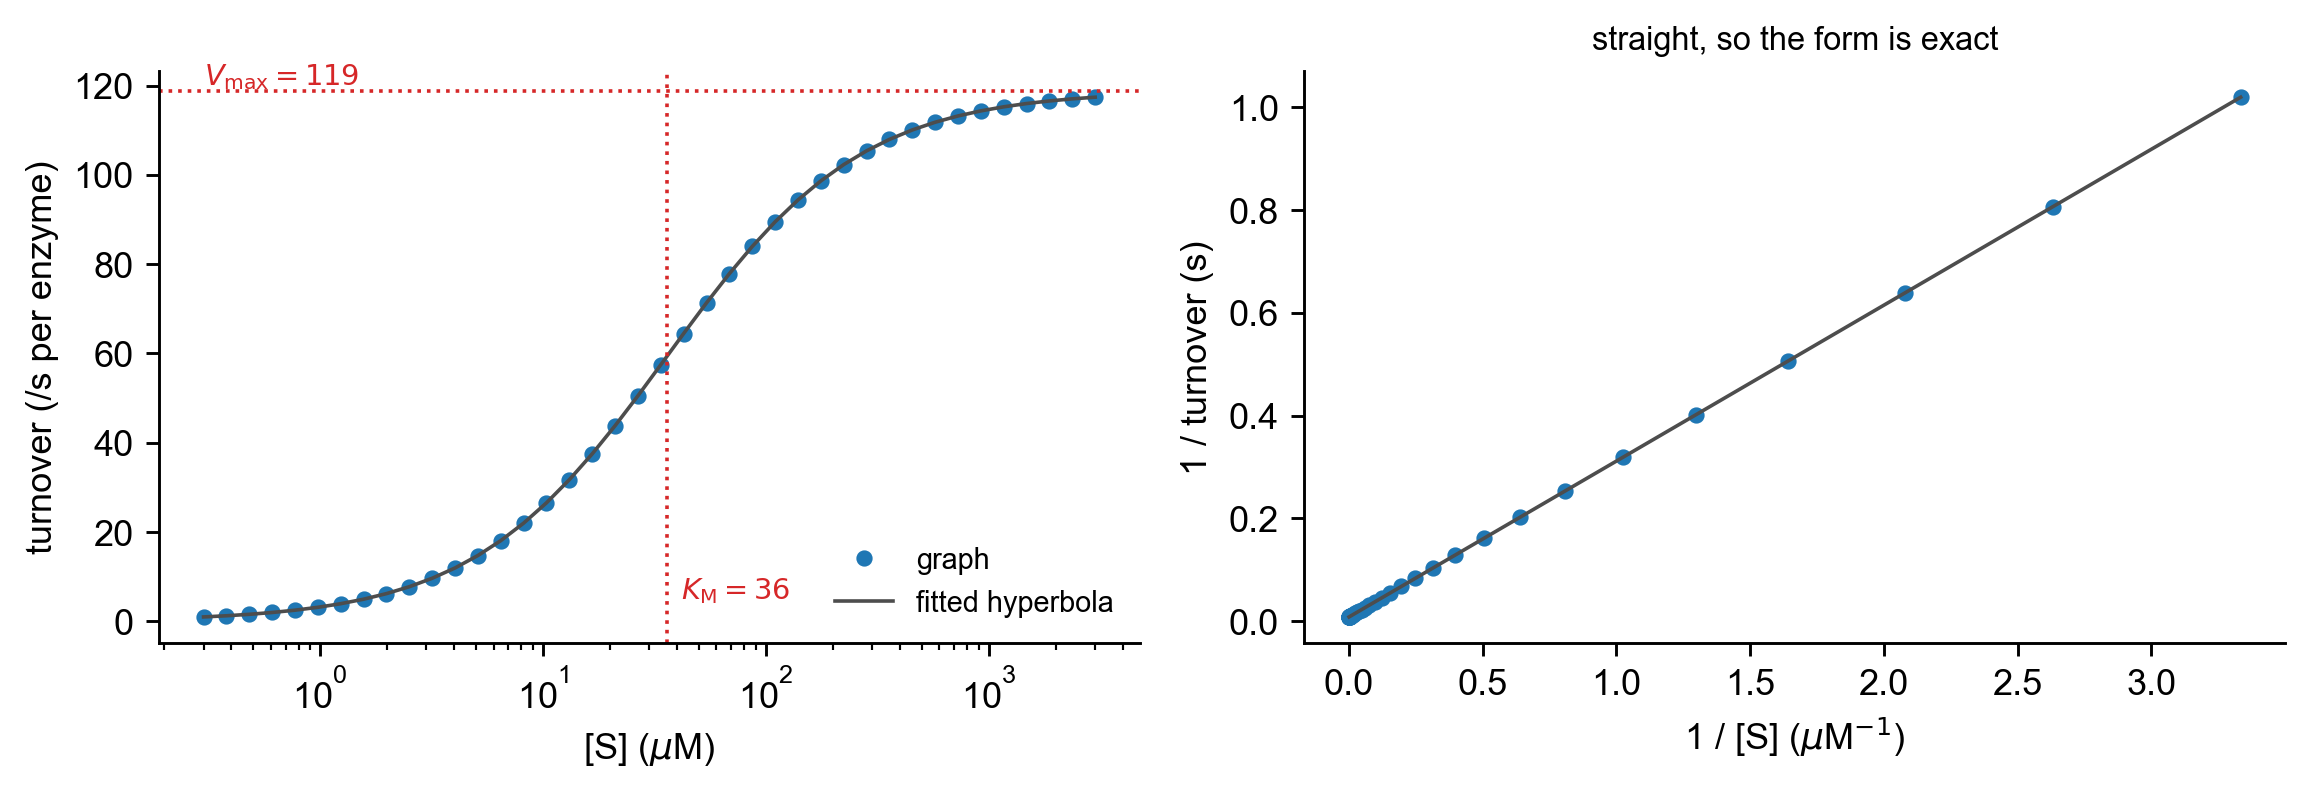

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3.2))
left.plot(SUBSTRATE, rate, "o", ms=3.5, color="tab:blue", label="graph")
left.plot(
    SUBSTRATE, predicted, "-", lw=1, color="0.3", label="fitted hyperbola"
)
left.axhline(VMAX, ls=":", lw=1, color="tab:red")
left.axvline(KM, ls=":", lw=1, color="tab:red")
left.annotate(
    f"$V_\\mathrm{{max}} = {VMAX:.0f}$",
    (SUBSTRATE[0], VMAX),
    fontsize=8,
    va="bottom",
    color="tab:red",
)
left.annotate(
    f"$K_\\mathrm{{M}} = {KM:.0f}$",
    (KM * 1.15, 5),
    fontsize=8,
    color="tab:red",
)
left.set(
    xscale="log", xlabel=r"[S] ($\mu$M)", ylabel="turnover (/s per enzyme)"
)
left.legend(fontsize=8, frameon=False)

right.plot(1 / SUBSTRATE, 1 / rate, "o", ms=3.5, color="tab:blue")
right.plot(
    1 / SUBSTRATE, intercept + slope / SUBSTRATE, "-", lw=1, color="0.3"
)
right.set(xlabel=r"1 / [S] ($\mu$M$^{-1}$)", ylabel="1 / turnover (s)")
right.set_title("straight, so the form is exact", fontsize=9)
fig.tight_layout()
plt.show()

The exactness is bought by removing product. Put some back and the
hyperbola fails, because the rate law acquires a reverse term. At
1 $\mu$M of product the fit is already 4% off, and by 100 $\mu$M it is
meaningless: the least-squares line through $1/v$ against
$1/[\mathrm{S}]$ returns a *negative* $K_\mathrm{M}$.

In [8]:
print("product      V_max        K_M     largest residual")
for product in (None, 1.0, 100.0):
    values = np.array([turnover(enzyme(s, product)) for s in SUBSTRATE])
    (b, a), *_ = np.linalg.lstsq(design, 1 / values, rcond=None)
    fitted = (1 / b) * SUBSTRATE / (a / b + SUBSTRATE)
    label = "absent" if product is None else f"{product:g} uM"
    print(
        f"{label:>9}  {1 / b:10.3f} {a / b:10.3f}"
        f"     {np.abs(fitted / values - 1).max():.2e}"
    )

product      V_max        K_M     largest residual


   absent     118.812     36.040     1.55e-14
     1 uM     123.430     37.902     3.83e-02


   100 uM       3.888     -1.417     1.35e+01


## 5. Which fate? The commitment to catalysis

A passage time says how long something takes. It cannot say which of
two things happened. `absorption_probabilities` answers that: given a
set of states treated as endpoints, it returns the probability that each
one is reached first, from every starting state.

The experimentally meaningful version is the **commitment to
catalysis** — the chance that a substrate, once bound, is turned over
rather than released. To ask it, the two fates have to be different
states, so product release has to lead somewhere other than back to free
enzyme. That is one edit to the scheme.

The answer is not the local branch ratio
$k_\mathrm{chem} / (k_\mathrm{off} + k_\mathrm{chem}) = 1/3$, because a
molecule that reaches EP can still fall back to ES and be released from
there. And it satisfies the textbook identity exactly:
$k_\mathrm{cat} / K_\mathrm{M} = k_\mathrm{on} \times$ commitment.

In [9]:
# The same mechanism with product release as an endpoint of its own
FATES = sr.Scheme(
    {
        ("E", "ES"): "k_on",
        ("ES", "E"): "k_off",
        ("ES", "EP"): "k_chem",
        ("EP", "ES"): "k_chem_rev",
        ("EP", "P"): "k_rel",
    }
)
fates = FATES.graph({k: v for k, v in RATES.items() if k != "k_rebind"})
reached = np.asarray(sr.absorption_probabilities(fates, ["E", "P"]))
commitment = reached[fates.index("ES"), fates.index("P")]

print("from ES, the substrate is")
print(f"  turned over  {commitment:.6f}")
print(f"  released     {reached[fates.index('ES'), fates.index('E')]:.6f}")
print(
    f"\nlocal branch k_chem / (k_off + k_chem) ="
    f" {RATES['k_chem'] / (RATES['k_off'] + RATES['k_chem']):.6f}"
)
print(f"\nk_cat / K_M            = {VMAX / KM:.8f} /uM/s")
print(f"k_on x commitment      = {RATES['k_on'] * commitment:.8f} /uM/s")

from ES, the substrate is
  turned over  0.329670
  released     0.670330

local branch k_chem / (k_off + k_chem) = 0.333333

k_cat / K_M            = 3.29670330 /uM/s
k_on x commitment      = 3.29670330 /uM/s


## 6. Where the turnover time goes

The mean time between products is $1/v$. It is tempting to read it as a
first passage time from free enzyme to product and back, but that is not
what it is: 11.45 ms against 11.32 ms, a discrepancy of about 1%.

The reason is the one that runs through this package. A first passage
time to EP ends at the *first arrival* in EP, and not every arrival
yields a product — some molecules fall back to ES and are released. The
turnover time counts only the arrivals that finish. So the sum of
passage times out and back is a lower bound on $1/v$, never equal to it.

`mean_residence_times` splits a passage time across the states it is
spent in, which is where the useful detail is: it says which state the
enzyme is waiting in, and how many times each state is revisited before
the target is reached.

In [10]:
graph = enzyme(100.0)
E, ES, EP = (graph.index(state) for state in ("E", "ES", "EP"))
out = float(sr.mean_first_passage_times(graph, "EP")[E])
back = float(sr.mean_first_passage_times(graph, "E")[EP])
print(f"1 / v                        {1 / turnover(graph) * 1e3:8.3f} ms")
print(f"MFPT(E -> EP) + MFPT(EP -> E) {(out + back) * 1e3:8.3f} ms")
print(f"  of which E -> EP            {out * 1e3:8.3f} ms")

residence = np.asarray(sr.mean_residence_times(graph, "EP"))
total = np.asarray(graph.rates).sum(axis=1)
print("\nwaiting for the first arrival in EP, starting from E:")
for state in ("E", "ES"):
    i = graph.index(state)
    print(
        f"  {state:>3}  {residence[E, i] * 1e3:7.3f} ms over"
        f" {residence[E, i] * total[i]:6.2f} visits"
    )

1 / v                          11.450 ms
MFPT(E -> EP) + MFPT(EP -> E)   11.324 ms
  of which E -> EP               8.000 ms



waiting for the first arrival in EP, starting from E:
    E    3.000 ms over   3.00 visits
   ES    5.000 ms over   3.00 visits


## 7. What an experiment that cannot resolve EP measures

Suppose the assay reports only whether the enzyme is occupied, lumping
ES and EP. `is_lumpable` says the partition is not exact — the two
states do not have the same total rate back to E — so a single observed
off-rate cannot be right, and which wrong answer you get depends on what
the instrument measures.

`passage_rates` inverts mean first passage times and so reproduces
measured dwell times. `coarse_grain` averages the microscopic rates over
the local steady state and so reproduces occupancies and fluxes. They
disagree by 8%, which is the size of the error in calling either one
"the" off-rate.

In [11]:
GROUPS = {"free": ["E"], "occupied": ["ES", "EP"]}
graph = enzyme(100.0)
print(f"lumpable: {sr.is_lumpable(graph, GROUPS)}\n")
print("                 free -> occupied   occupied -> free")
for name, reduce in (
    ("passage_rates", sr.passage_rates),
    ("coarse_grain", sr.coarse_grain),
):
    macro = np.asarray(reduce(graph, GROUPS).rates)
    print(f"  {name:<14} {macro[0, 1]:14.2f} {macro[1, 0]:18.2f}")

lumpable: False

                 free -> occupied   occupied -> free


  passage_rates         1000.00             334.19
  coarse_grain          1000.00             360.40


## 8. The pre-steady-state transient

`propagate` solves the master equation exactly, so the approach to the
steady state comes for free — and it is where the classic
pre-steady-state experiment lives.

Start with free enzyme and integrate the product-forming rate. Released
product shows a **lag**: nothing comes out until ES and EP have filled.
But count product *made at the active site*, released or not, and when
release is the slow step the same graph shows the textbook **burst** of
close to one product per enzyme, formed in the first turnover and then
held up waiting for release. Both curves have the same steady-state
slope; the intercept is the whole signal.

k_rel =   300          released: slope   87.336 /s   intercept -0.2422 products
k_rel =   300  made at the site: slope   87.336 /s   intercept +0.0489 products
k_rel =     8          released: slope    7.279 /s   intercept -0.0534 products
k_rel =     8  made at the site: slope    7.279 /s   intercept +0.8565 products


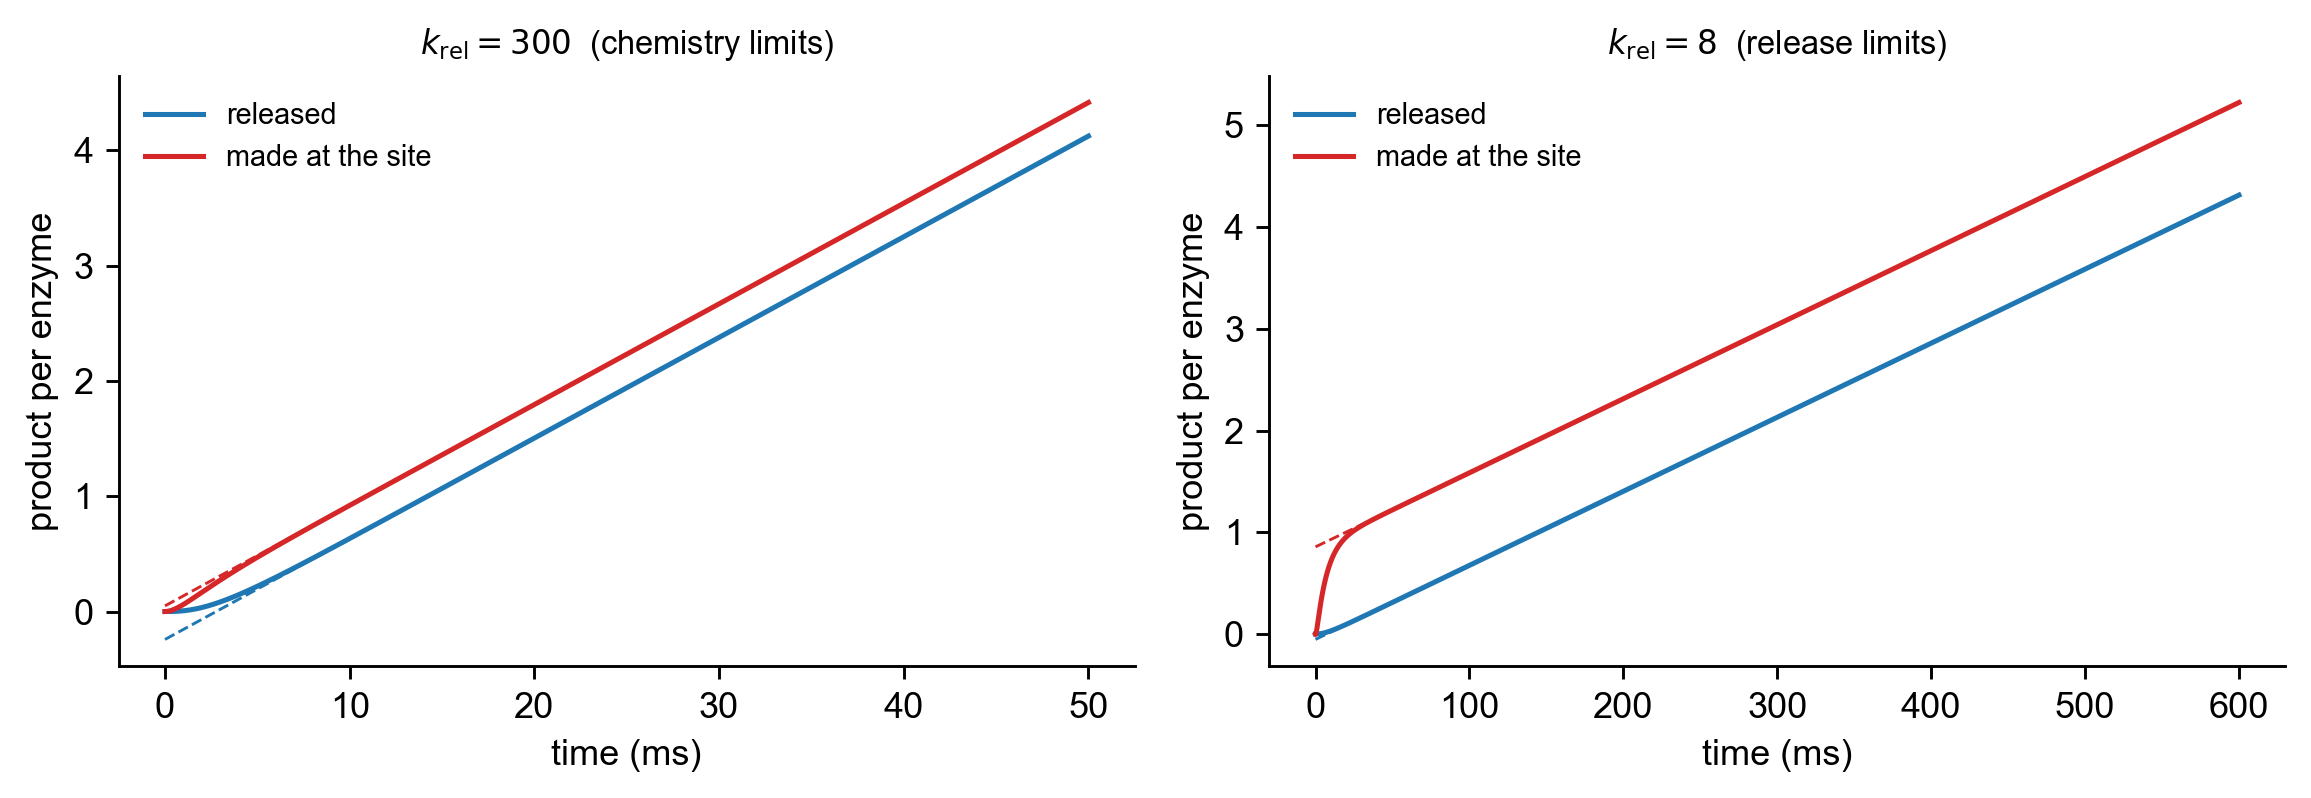

In [12]:
def accumulate(
    occupancy: np.ndarray, times: np.ndarray, release: float, site: int
) -> tuple[np.ndarray, np.ndarray]:
    """Product released, and product made whether released or not."""
    held = occupancy[:, site]
    flow = held * release
    released = np.concatenate(
        [[0.0], np.cumsum(np.diff(times) * (flow[1:] + flow[:-1]) / 2)]
    )
    return released, released + held


def evolve(graph: sr.Graph, times: np.ndarray) -> np.ndarray:
    return np.asarray(sr.propagate(graph, {"E": 1.0}, times))


fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=False)
for ax, release, span in zip(axes, (300.0, 8.0), (0.05, 0.6)):
    graph = enzyme(100.0, k_rel=release)
    times = np.linspace(0, span, 4001)
    released, made = accumulate(
        evolve(graph, times), times, release, graph.index("EP")
    )
    late = times > span * 0.6
    for label, curve, color in (
        ("released", released, "tab:blue"),
        ("made at the site", made, "tab:red"),
    ):
        slope, intercept = np.polyfit(times[late], curve[late], 1)
        ax.plot(times * 1e3, curve, lw=1.4, color=color, label=label)
        ax.plot(
            times * 1e3,
            intercept + slope * times,
            ls="--",
            lw=0.8,
            color=color,
        )
        print(
            f"k_rel = {release:5.0f}  {label:>16}:"
            f" slope {slope:8.3f} /s   intercept {intercept:+.4f} products"
        )
    ax.set(
        xlabel="time (ms)",
        ylabel="product per enzyme",
        title=f"$k_\\mathrm{{rel}} = {release:.0f}$"
        + ("  (chemistry limits)" if release > 50 else "  (release limits)"),
    )
    ax.title.set_size(9)
    ax.legend(fontsize=8, frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## 9. A stopped-flow dead time

`propagate` assumes the rate constants hold still. A real mixing
experiment does not deliver its substrate instantaneously, and since
$[\mathrm{S}]$ lives inside a rate constant here, a finite dead time
makes that rate constant a function of time. `integrate` is for exactly
that: it takes the graph as a function of $t$ and hands the master
equation to a stiff solver.

One implementation note. The graph has to be built with
`Graph.with_log_rates`, not `Scheme.graph`, because the scheme checks
that its rates are positive and that check cannot run on a traced value
inside the solver. `with_log_rates` is the documented way to swap in
rates that JAX is differentiating or integrating through.

The steady-state slope is untouched, as it must be — mixing cannot
change the turnover number. What moves is the intercept: an apparent lag
of 2.8 ms becomes 4.2 ms, so a dead time of 2 ms has inflated the
measured lag by half again. Reading a lag as a property of the enzyme,
without modelling the mixing, would get the mechanism wrong.

In [13]:
MIX = 2.0e-3  # s, the mixing dead time
base = enzyme(100.0)
FROM_E, TO_ES = base.index("E"), base.index("ES")


def mixing(t: jax.Array) -> sr.Graph:
    """The graph at time t, with substrate still arriving."""
    arrived = 100.0 * (1 - jnp.exp(-t / MIX))
    return base.with_log_rates(
        base.log_rates.at[FROM_E, TO_ES].set(jnp.log(RATES["k_on"] * arrived))
    )


times = np.linspace(0, 0.05, 500)
histories = {
    "instant jump": evolve(base, times),
    f"mixed in over {MIX * 1e3:.0f} ms": np.asarray(
        sr.integrate(mixing, {"E": 1.0}, times)
    ),
}
curves = {}
for label, occupancy in histories.items():
    released, _ = accumulate(
        occupancy, times, RATES["k_rel"], base.index("EP")
    )
    curves[label] = released
    late = times > 0.03
    slope, intercept = np.polyfit(times[late], released[late], 1)
    print(
        f"{label:>22}: slope {slope:8.3f} /s   intercept {intercept:+.4f}"
        f"   apparent lag {-intercept / slope * 1e3:6.3f} ms"
    )

          instant jump: slope   87.336 /s   intercept -0.2422   apparent lag  2.773 ms
    mixed in over 2 ms: slope   87.336 /s   intercept -0.3625   apparent lag  4.151 ms


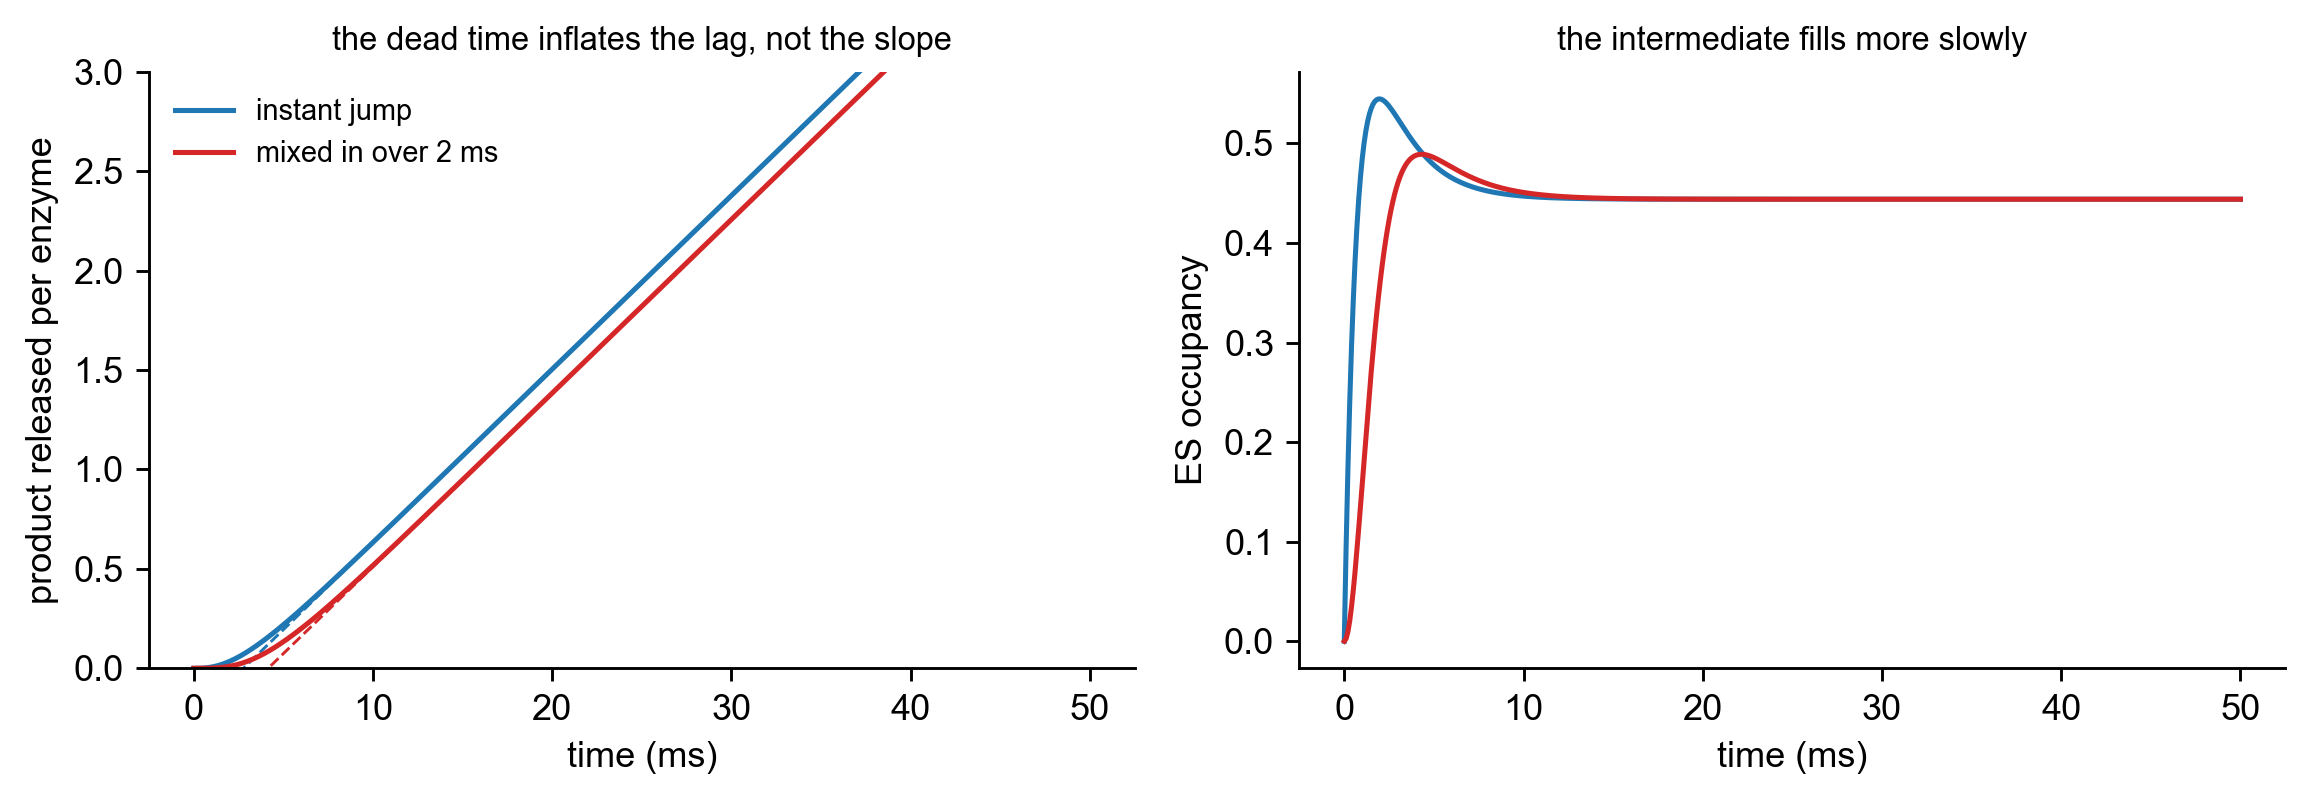

In [14]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3.2))
for (label, curve), color in zip(curves.items(), ("tab:blue", "tab:red")):
    late = times > 0.03
    slope, intercept = np.polyfit(times[late], curve[late], 1)
    left.plot(times * 1e3, curve, lw=1.4, color=color, label=label)
    left.plot(
        times * 1e3, intercept + slope * times, ls="--", lw=0.8, color=color
    )
left.set(
    xlabel="time (ms)",
    ylabel="product released per enzyme",
    ylim=(0, 3),
    title="the dead time inflates the lag, not the slope",
)
left.title.set_size(9)
left.legend(fontsize=8, frameon=False, loc="upper left")

for (label, occupancy), color in zip(
    histories.items(), ("tab:blue", "tab:red")
):
    right.plot(
        times * 1e3,
        occupancy[:, base.index("ES")],
        lw=1.4,
        color=color,
        label=label,
    )
right.set(
    xlabel="time (ms)",
    ylabel="ES occupancy",
    title="the intermediate fills more slowly",
)
right.title.set_size(9)
fig.tight_layout()
plt.show()

## 10. Single molecules

`simulate` runs individual enzymes as continuous-time Markov jump
processes. Averaged over molecules it reproduces the flux, and the
waiting time in the free state is exponential with the total rate out of
it — which at 100 $\mu$M is the binding rate, so single-molecule
turnovers are a way of measuring $k_\mathrm{on}[\mathrm{S}]$ directly.

`dwells` with a target measures something different and slower: the time
from arriving in a state to *first reaching* the target, so an excursion
that comes straight back does not end the dwell. `dwell_rates` gives
both expectations and `dwell_diagram` draws the sample against them.

In [15]:
graph = enzyme(100.0)
trace = sr.simulate(graph, {"E": 300}, 1.0, seed=0)
made = (
    (trace.sources == graph.index("EP")) & (trace.targets == graph.index("E"))
).sum()
print(trace)
print(
    f"turnovers: {made / 300:.2f} /s per enzyme, against v = {turnover(graph):.2f}"
)
print("\ndwell in E:", sr.dwell_rates(graph, "E", "EP"))

Trajectory(molecules=300, jumps=185631)
turnovers: 87.04 /s per enzyme, against v = 87.34

dwell in E: {'microscopic': 999.9999999999998, 'observable': 124.99999999999994}


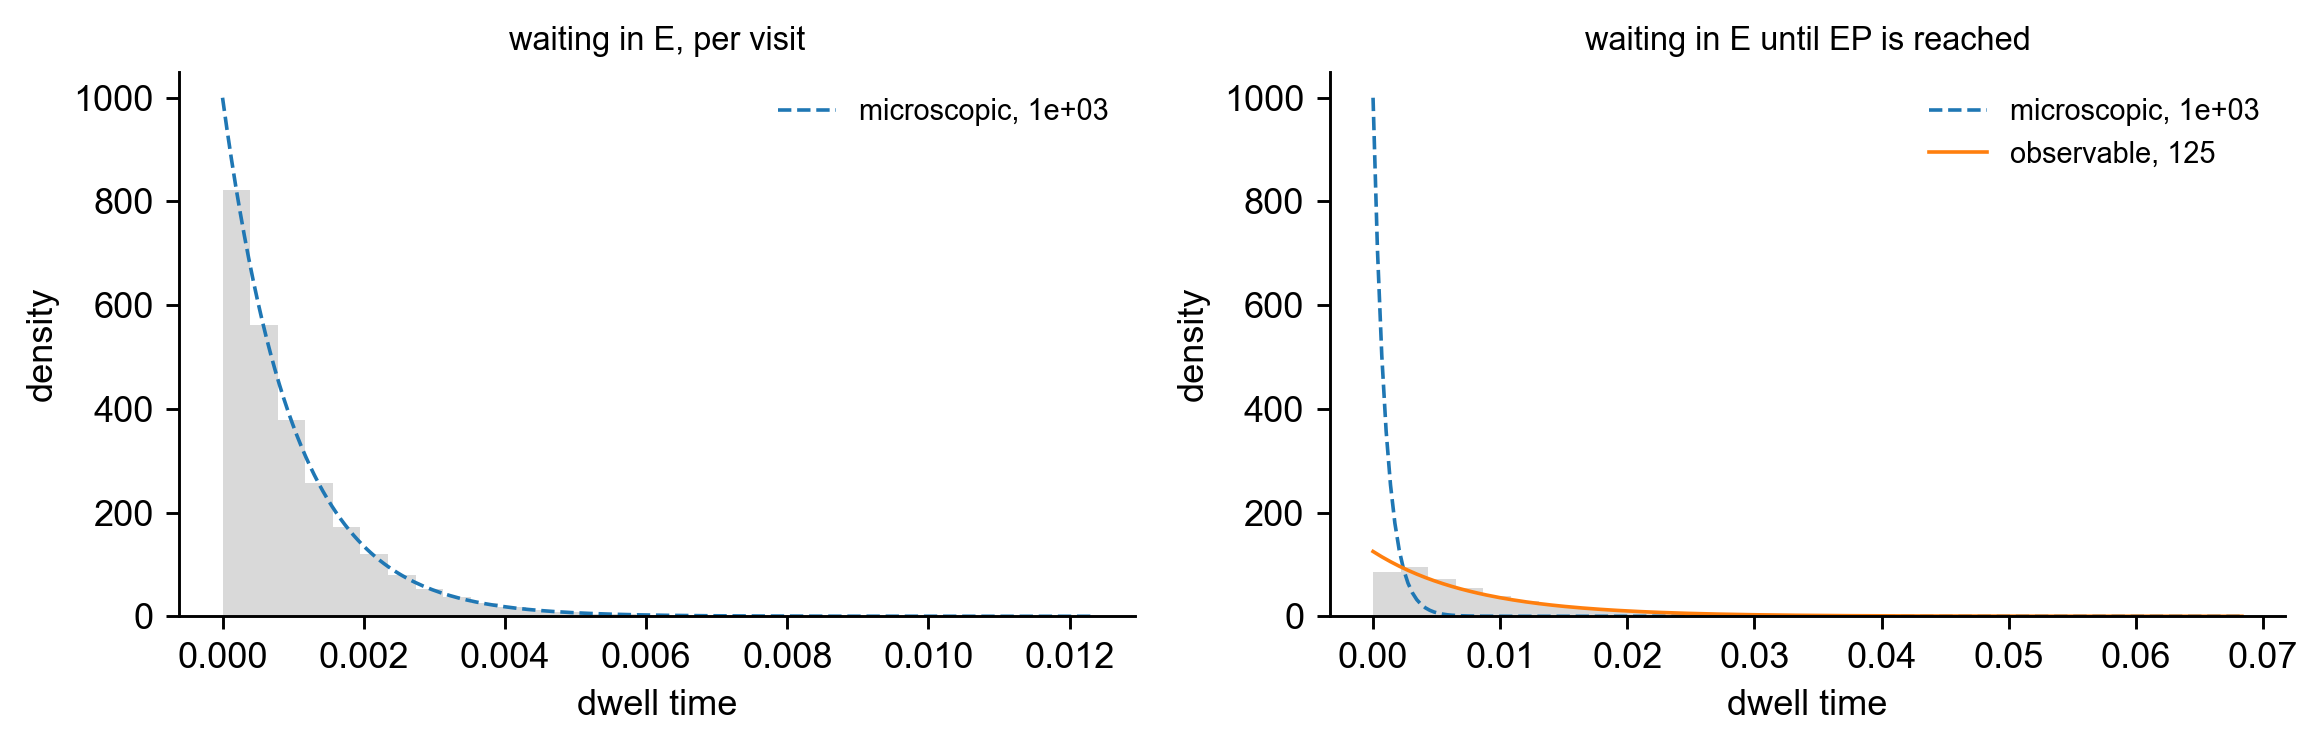

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
sr.dwell_diagram(graph, trace.dwells("E"), "E", ax=axes[0])
axes[0].set_title("waiting in E, per visit", fontsize=9)
sr.dwell_diagram(graph, trace.dwells("E", until="EP"), "E", "EP", ax=axes[1])
axes[1].set_title("waiting in E until EP is reached", fontsize=9)
for ax in axes:
    ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## 11. Traces of individual enzymes

The averages above hide what a single enzyme actually does. `path`
returns the times and states one molecule visited, which is the raw
material for the plot a single-molecule experiment produces: one row per
enzyme, the state as a function of time, with a mark at every product
release.

At 20 $\mu$M, below $K_\mathrm{M}$, the enzyme spends most of its time
free and waiting, and the turnover count over 150 ms varies widely: a
mean of 6.4, but anywhere from 2 to 12 across sixty identical enzymes
with identical rate constants. That spread is not variation between
molecules — it is the same mechanism seen one molecule at a time.

The size of the spread says something the mean cannot. A single
rate-limiting step would make turnovers a Poisson process, with a
standard deviation equal to the square root of the mean, 2.52 here.
The measured spread is 2.03, giving a Fano factor of 0.64: noticeably
*more regular* than Poisson. That is the signature of a turnover made of
several steps in series, none of them dominant, and in single-molecule
enzymology it is called the randomness parameter — a way of counting
rate-limiting steps without resolving any of them.

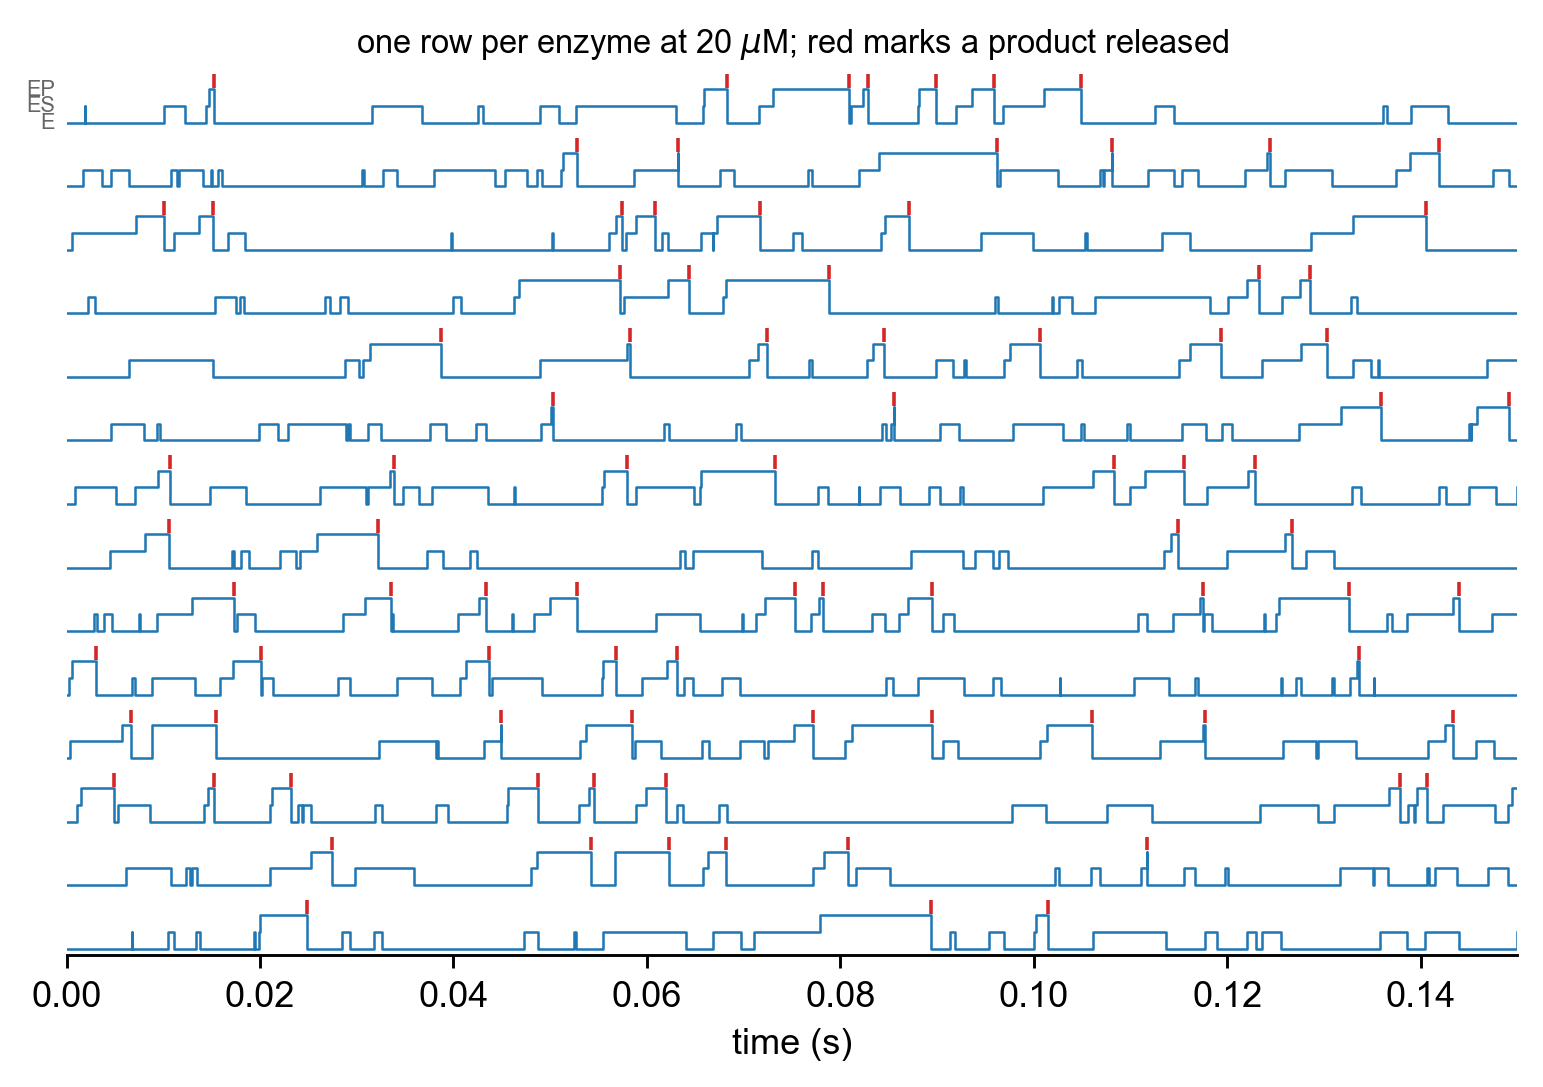

turnovers in 150 ms: mean 6.38, spread 2 to 12, expected 6.36
a Poisson process would spread by 2.52, measured 2.03  ->  Fano factor 0.64


In [17]:
WINDOW, ROWS, MOLECULES = 0.15, 14, 60
graph = enzyme(20.0)
E, ES, EP = (graph.index(state) for state in ("E", "ES", "EP"))
trace = sr.simulate(graph, {"E": MOLECULES}, WINDOW * 2, seed=3)

fig, axes = plt.subplots(ROWS, 1, figsize=(7.2, 4.4), sharex=True, sharey=True)
counted = []
for molecule in range(MOLECULES):
    when, visited = trace.path(molecule)
    inside = when <= WINDOW
    made = when[1:][(visited[:-1] == EP) & (visited[1:] == E)]
    counted.append(int((made <= WINDOW).sum()))
    if molecule >= ROWS:
        continue
    ax = axes[molecule]
    ax.step(
        np.append(when[inside], WINDOW),
        np.append(visited[inside], visited[inside][-1]),
        where="post",
        color="tab:blue",
        lw=0.7,
    )
    ax.plot(
        made[made <= WINDOW],
        np.full((made <= WINDOW).sum(), 2.5),
        "|",
        color="tab:red",
        ms=4,
        mew=1.0,
    )
    ax.set(xlim=(0, WINDOW), ylim=(-0.4, 2.9), yticks=())
    ax.tick_params(left=False, bottom=False)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(False)

for level, label in ((2, "EP"), (1, "ES"), (0, "E")):
    axes[0].text(
        -0.008,
        (level + 0.4) / 3.3,
        label,
        fontsize=6,
        color="0.4",
        ha="right",
        va="center",
        transform=axes[0].transAxes,
    )
axes[0].set_title(
    f"one row per enzyme at 20 $\\mu$M; red marks a product released",
    fontsize=9,
)
axes[-1].set_xlabel("time (s)")
axes[-1].spines["bottom"].set_visible(True)
axes[-1].tick_params(bottom=True)
fig.subplots_adjust(hspace=0.15)
plt.show()

print(
    f"turnovers in {WINDOW * 1e3:.0f} ms: mean {np.mean(counted):.2f},"
    f" spread {np.min(counted)} to {np.max(counted)},"
    f" expected {turnover(graph) * WINDOW:.2f}"
)
print(
    f"a Poisson process would spread by"
    f" {np.sqrt(turnover(graph) * WINDOW):.2f}, measured {np.std(counted):.2f}"
    f"  ->  Fano factor {np.var(counted) / np.mean(counted):.2f}"
)

## 12. The enzyme runs backwards

An enzyme is a catalyst, so it cannot choose a direction: it accelerates
whichever way the thermodynamics points. Raising the product
concentration reduces the driving force, and `cycle_affinity` tracks it
in kcal/mol.

At one particular ratio the affinity is exactly zero. There the graph
becomes detailed balanced — `is_detailed_balanced` says so — the flux
stops, and only then does the graph have a free energy landscape at all.
`energy_diagram` refuses to draw a driven graph, and rightly: without
detailed balance the two directions of a transition imply two different
barrier heights, so there is no landscape to draw. Past the stall point
the flux changes sign and the enzyme synthesizes substrate from product.
The subsection below is the other half of that story: what to draw when
the cycle *is* driven.

Barrier heights need one more thing a graph does not contain: the rate
constant of a hypothetical barrierless step. That `prefactor` shifts
every barrier by the same amount, so it leaves their differences — the
only part that affects any rate — untouched. The $10^6$ /s used below is
the value the Marklund notebook uses, chosen simply to put the barriers
above the states.

In [18]:
SUBSTRATE_HELD = 100.0
STALL = (
    RATES["k_on"]
    * RATES["k_chem"]
    * RATES["k_rel"]
    / (RATES["k_off"] * RATES["k_chem_rev"] * RATES["k_rebind"])
) * SUBSTRATE_HELD
print(
    f"the cycle stalls at [P] = {STALL:.0f} uM for [S] = {SUBSTRATE_HELD:.0f} uM\n"
)

product = np.geomspace(1.0, 1e6, 60)
affinity = np.array(
    [sr.cycle_affinity(enzyme(SUBSTRATE_HELD, p), CYCLE) for p in product]
)
flux = np.array([turnover(enzyme(SUBSTRATE_HELD, p)) for p in product])

poised = enzyme(SUBSTRATE_HELD, STALL)
print(
    f"at the stall point: affinity {sr.cycle_affinity(poised, CYCLE):+.2e}"
    f" kcal/mol,  v {turnover(poised):+.2e} /s"
)
print(f"  detailed balanced: {sr.is_detailed_balanced(poised)}")
# Only a reversible graph has a real spectrum, so this is the one
# concentration at which the relaxation times are defined
print(
    "  relaxation times:",
    ", ".join(f"{time * 1e3:.3f} ms" for time in sr.relaxation_times(poised)),
)
try:
    sr.energy_diagram(enzyme(SUBSTRATE_HELD, 1.0))
except ValueError as error:
    print(f"  a driven graph has no landscape: {error}")
plt.close()

the cycle stalls at [P] = 30000 uM for [S] = 100 uM



at the stall point: affinity -5.26e-16 kcal/mol,  v -2.66e-15 /s
  detailed balanced: True


  relaxation times: 1.662 ms, 0.032 ms


  a driven graph has no landscape: barrier heights require detailed balance


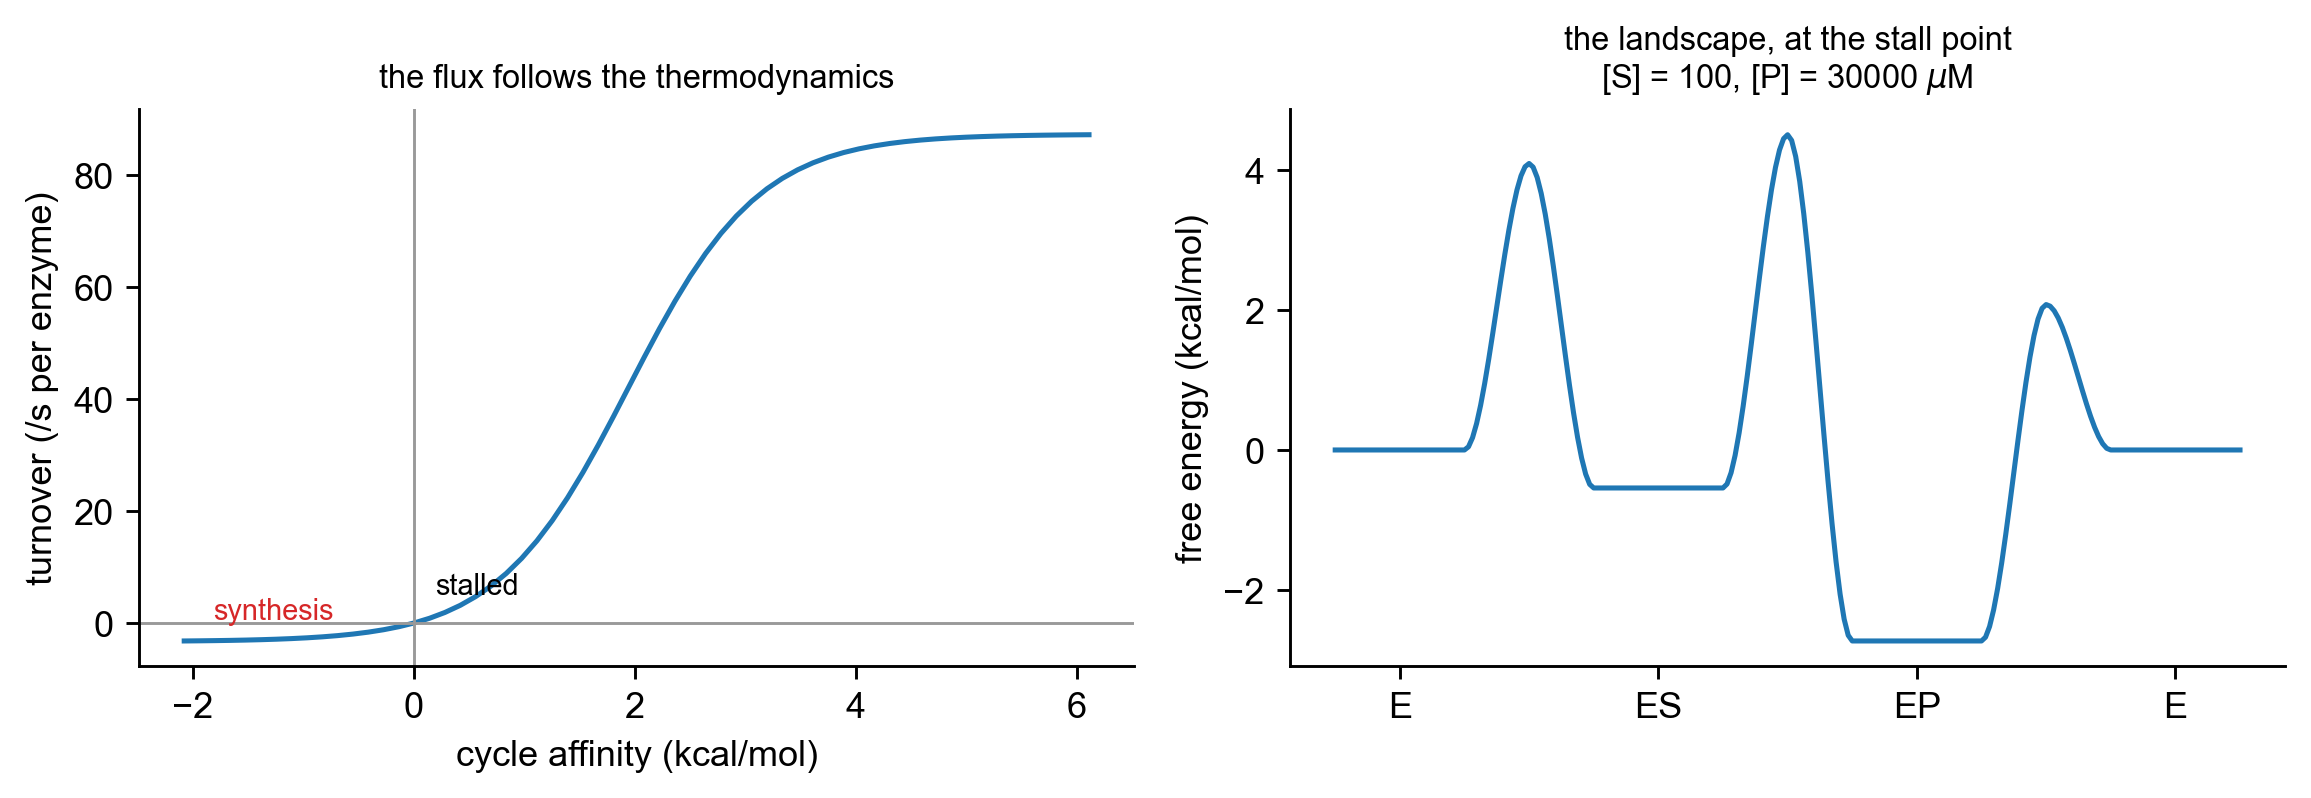

In [19]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3.2))
left.plot(affinity, flux, "-", lw=1.4, color="tab:blue")
left.axhline(0, lw=0.8, color="0.6")
left.axvline(0, lw=0.8, color="0.6")
left.annotate(
    "stalled", (0, 0), textcoords="offset points", xytext=(6, 8), fontsize=8
)
left.annotate(
    "synthesis",
    (affinity.min(), flux.min()),
    textcoords="offset points",
    xytext=(8, 6),
    fontsize=8,
    color="tab:red",
)
left.set(
    xlabel="cycle affinity (kcal/mol)",
    ylabel="turnover (/s per enzyme)",
    title="the flux follows the thermodynamics",
)
left.title.set_size(9)

# The prefactor is the rate constant of a barrierless step, and only
# shifts every barrier together; 1e6 /s puts them all above the states
sr.energy_diagram(
    poised,
    CYCLE + ["E"],
    reference="E",
    prefactor=1e6,
    ax=right,
    lw=1.4,
    color="tab:blue",
)
right.set_title(
    f"the landscape, at the stall point\n"
    f"[S] = {SUBSTRATE_HELD:.0f}, [P] = {STALL:.0f} $\\mu$M",
    fontsize=9,
)
fig.tight_layout()
plt.show()

### The landscape a driven cycle does have

That refusal is about the *cycle*, and it is not the statement that a
driven enzyme has no landscape. The energy diagrams drawn for enzymes and
motors are not wrong; they are drawn on a different graph.

One turnover does not return the system to where it started. The enzyme
comes back to E, but the bath has lost a substrate and gained a product,
so the free energy has fallen by the affinity. Indexing the states by
turnover number makes that explicit — E1 is the same enzyme as E0 with one
more product made — and the result is a chain. A chain has no cycle, so
`is_detailed_balanced` holds at *every* product concentration, and the
landscape exists however hard the cycle is driven.

What it looks like is a staircase, descending by one affinity per
turnover. At the stall concentration the treads are level and the
landscape is periodic, which is the equilibrium picture above repeated;
past the stall point the staircase climbs, and the enzyme walks down it
the other way, making substrate from product. Every tread is the same
three-state motif, and only its height changes.

The three curves below coincide until the release step, which is the one
transition that carries the product's chemical potential — that is where
the drive enters, and nowhere else. This is Hill's diagram construction,
and it says where the ambiguity went: on a closed cycle the barrier
between two states is not single-valued, since going round once returns
you to the same state at a different free energy. Unrolled, each state
appears once per turnover, and there is nothing left to be ambiguous.


    [P] uM  balanced   drop per turnover   -affinity


         1      True             -6.1079     -6.1079
     30000      True             +0.0000     +0.0000
   1000000      True             +2.0776     +2.0776


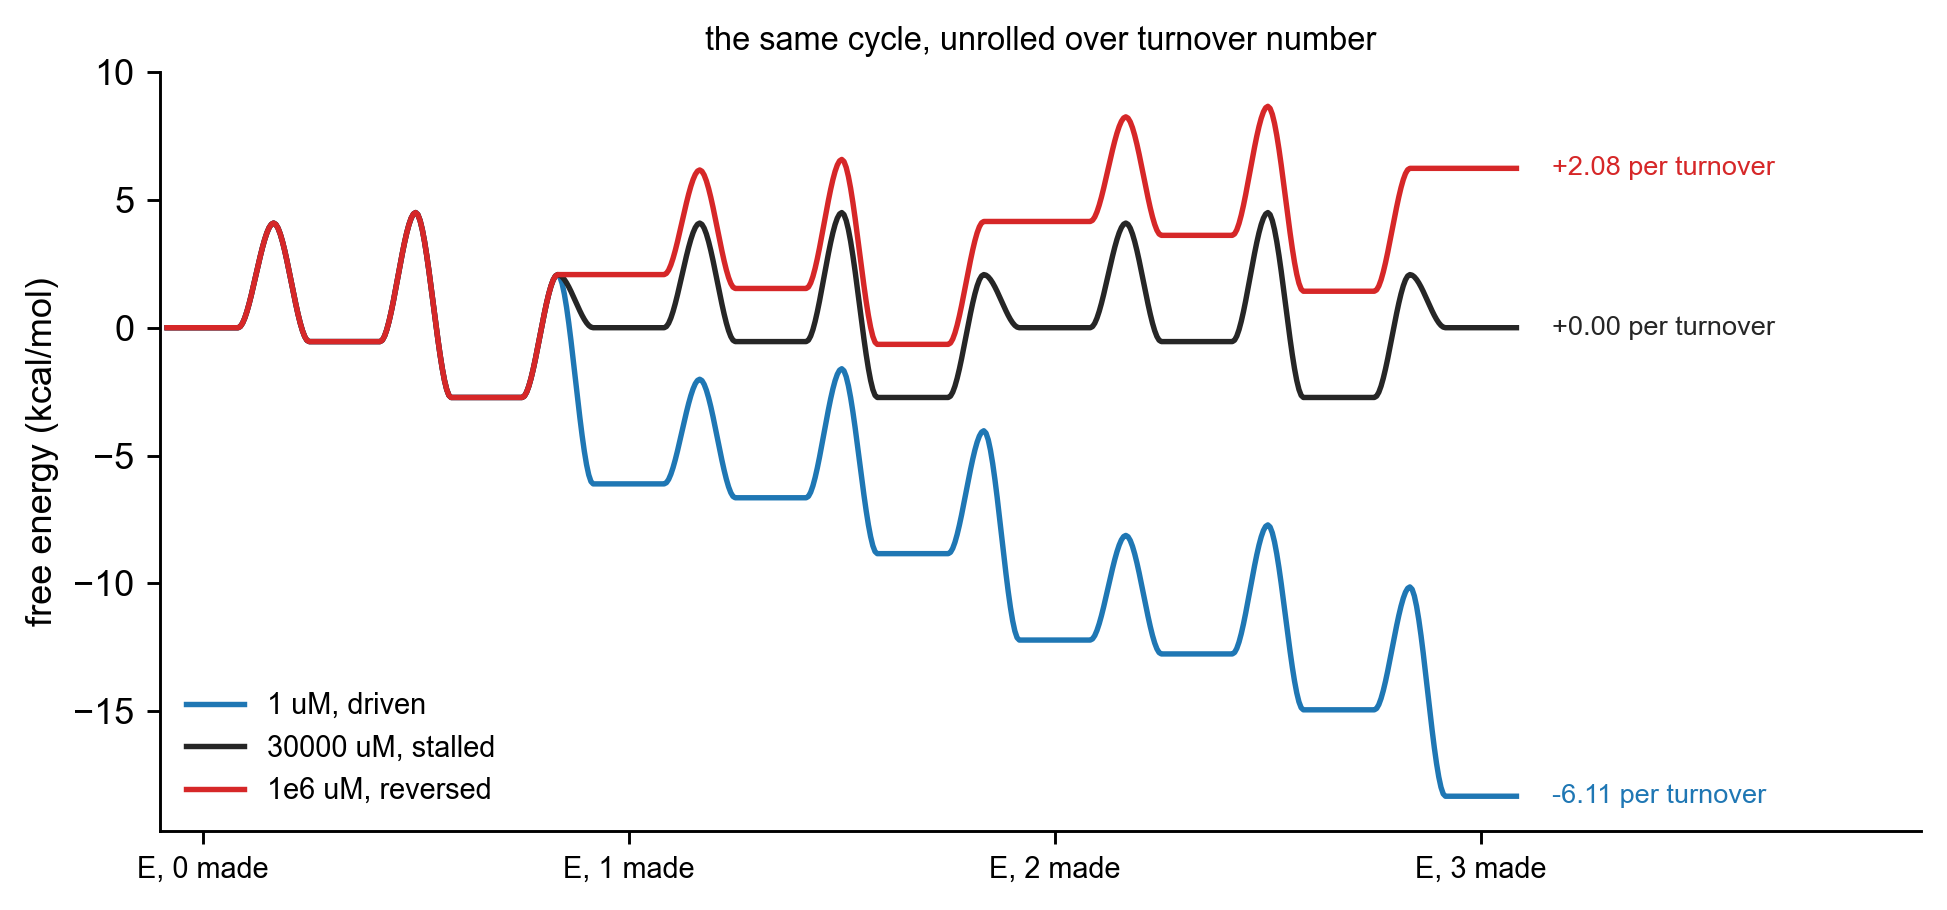

In [20]:
TURNOVERS = 3


def unrolled(
    substrate: float, product: float, turnovers: int = TURNOVERS
) -> sr.Graph:
    """The cycle indexed by turnover number, which makes it a chain.

    State E1 is the same enzyme as E0 with one more product made, so the
    two differ by whatever the bath supplied. A chain has no cycle, so
    detailed balance holds however hard the cycle is driven.
    """
    edges = {}
    for n in range(turnovers):
        edges[(f"E{n}", f"ES{n}")] = RATES["k_on"] * substrate
        edges[(f"ES{n}", f"E{n}")] = RATES["k_off"]
        edges[(f"ES{n}", f"EP{n}")] = RATES["k_chem"]
        edges[(f"EP{n}", f"ES{n}")] = RATES["k_chem_rev"]
        edges[(f"EP{n}", f"E{n + 1}")] = RATES["k_rel"]
        edges[(f"E{n + 1}", f"EP{n}")] = RATES["k_rebind"] * product
    return sr.Graph(edges)


LADDER = [
    state
    for n in range(TURNOVERS)
    for state in (f"E{n}", f"ES{n}", f"EP{n}")
] + [f"E{TURNOVERS}"]

CASES = {
    "1 uM, driven": (1.0, "tab:blue"),
    f"{STALL:.0f} uM, stalled": (STALL, "0.15"),
    "1e6 uM, reversed": (1e6, "tab:red"),
}

print(f"{'[P] uM':>10}{'balanced':>10}{'drop per turnover':>20}"
      f"{'-affinity':>12}")
for label, (product, _) in CASES.items():
    chain = unrolled(SUBSTRATE_HELD, product)
    energies = np.asarray(sr.free_energies(chain, reference="E0"))
    drops = np.diff(
        [energies[chain.index(f"E{n}")] for n in range(TURNOVERS + 1)]
    )
    affinity = sr.cycle_affinity(enzyme(SUBSTRATE_HELD, product), CYCLE)
    print(f"{product:10.0f}{str(sr.is_detailed_balanced(chain)):>10}"
          f"{drops.mean():+20.4f}{-affinity:+12.4f}")

fig, ax = plt.subplots(figsize=(7.6, 3.6))
for label, (product, color) in CASES.items():
    chain = unrolled(SUBSTRATE_HELD, product)
    sr.energy_diagram(
        chain, LADDER, reference="E0", prefactor=1e6, ax=ax, lw=1.5,
        color=color, label=label,
    )
    energies = np.asarray(sr.free_energies(chain, reference="E0"))
    drop = energies[chain.index("E1")] - energies[chain.index("E0")]
    ax.annotate(f"{drop:+.2f} per turnover",
                (TURNOVERS * 3 + 0.5, energies[chain.index(f"E{TURNOVERS}")]),
                fontsize=7.5, color=color, va="center")
ax.set_xticks(range(0, TURNOVERS * 3 + 1, 3))
ax.set_xticklabels([f"E, {n} made" for n in range(TURNOVERS + 1)], fontsize=8)
ax.set_xlim(-0.3, TURNOVERS * 3 + 3.1)
ax.set_title("the same cycle, unrolled over turnover number", fontsize=9)
ax.legend(fontsize=8, frameon=False, loc="lower left")
fig.tight_layout()
plt.show()


## 13. Mutations

A `Mutation` perturbs the *free energies* of a graph rather than its
rate constants: raising the energy of a state speeds up every transition
out of it, and raising a barrier slows both directions of one
transition. Either way the result stays thermodynamically consistent, so
a mutant of a graph poised at its stall point is still poised at its
stall point — which is why the landscapes below can all be drawn.

Three mutants, and one result worth the whole section. Stabilizing the
ES complex by 1.5 kcal/mol — tighter substrate binding — drops
$K_\mathrm{M}$ eightfold, from 36 to 4.5 $\mu$M, which looks like a
better enzyme. It also drops $k_\mathrm{cat}$ eightfold. And
$k_\mathrm{cat}/K_\mathrm{M}$, which is what governs the rate when
substrate is scarce, is left **exactly** unchanged at 3.296703.

That is not a coincidence and not a numerical accident. Section 5 showed
$k_\mathrm{cat}/K_\mathrm{M} = k_\mathrm{on} \times$ commitment, and
the commitment is a ratio of the rates leaving ES. Stabilizing ES scales
all of them by the same factor, so the ratio cannot move. Tighter
binding buys nothing at low substrate. Lowering the barrier to chemistry
does: it raises the commitment, and with it
$k_\mathrm{cat}/K_\mathrm{M}$.

In [21]:
MUTANTS = {
    "wild type": (),
    "ES stabilized 1.5": (sr.Mutation(states={"ES": -1.5}, name="tighter"),),
    "chemistry barrier +2": (
        sr.Mutation(barriers={("ES", "EP"): 2.0}, name="slower"),
    ),
    "chemistry barrier -1": (
        sr.Mutation(barriers={("ES", "EP"): -1.0}, name="faster"),
    ),
}


def kinetics(
    mutations: tuple[sr.Mutation, ...],
) -> tuple[float, float, np.ndarray]:
    """k_cat, K_M and the turnover curve of a mutant."""
    values = np.array(
        [turnover(enzyme(s).mutate(*mutations)) for s in SUBSTRATE]
    )
    (b, a), *_ = np.linalg.lstsq(design, 1 / values, rcond=None)
    return 1 / b, a / b, values


print("mutant                  k_cat        K_M   k_cat/K_M")
fitted = {}
for name, mutations in MUTANTS.items():
    kcat, km, values = kinetics(mutations)
    fitted[name] = (kcat, km, values)
    print(f"{name:22} {kcat:8.3f} {km:10.3f} {kcat / km:11.6f}")

mutant                  k_cat        K_M   k_cat/K_M
wild type               118.812     36.040    3.296703


ES stabilized 1.5        14.869      4.510    3.296703
chemistry barrier +2      6.683     39.777    0.168017


chemistry barrier -1    230.346     32.322    7.126656


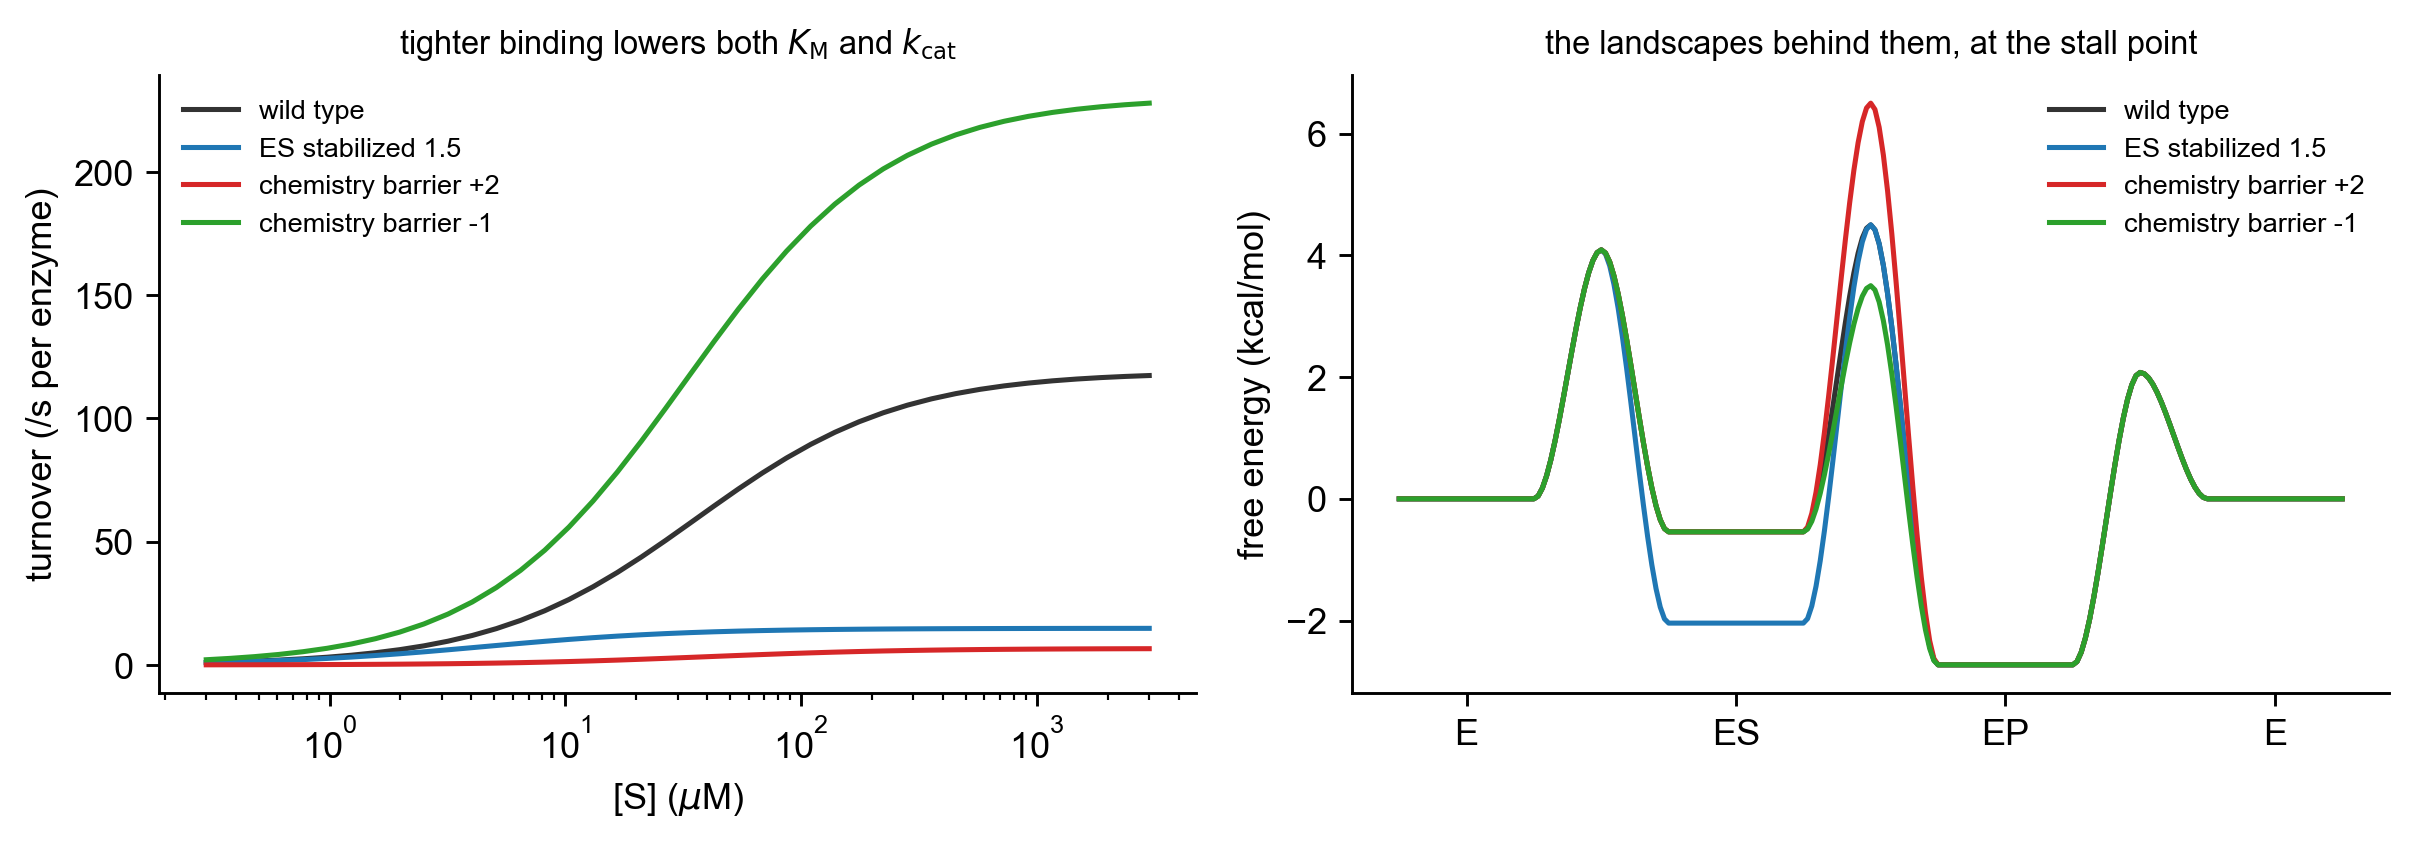

every mutant is still detailed balanced:
  wild type               True, affinity -5.3e-16 kcal/mol
  ES stabilized 1.5       True, affinity -5.3e-16 kcal/mol
  chemistry barrier +2    True, affinity -5.3e-16 kcal/mol
  chemistry barrier -1    True, affinity -5.3e-16 kcal/mol


In [22]:
COLORS = dict(zip(MUTANTS, ("0.2", "tab:blue", "tab:red", "tab:green")))
fig, (left, right) = plt.subplots(1, 2, figsize=(9.4, 3.4))
for name, (kcat, km, values) in fitted.items():
    left.plot(SUBSTRATE, values, lw=1.4, color=COLORS[name], label=name)
left.set(
    xscale="log",
    xlabel=r"[S] ($\mu$M)",
    ylabel="turnover (/s per enzyme)",
    title="tighter binding lowers both $K_\\mathrm{M}$ and $k_\\mathrm{cat}$",
)
left.title.set_size(9)
left.legend(fontsize=7.5, frameon=False)

# Mutating a poised graph leaves it poised, so every landscape exists
for name, mutations in MUTANTS.items():
    sr.energy_diagram(
        poised.mutate(*mutations),
        CYCLE + ["E"],
        reference="E",
        prefactor=1e6,
        ax=right,
        lw=1.4,
        color=COLORS[name],
        label=name,
    )
right.set_title("the landscapes behind them, at the stall point", fontsize=9)
right.legend(fontsize=7.5, frameon=False)
fig.tight_layout()
plt.show()

print("every mutant is still detailed balanced:")
for name, mutations in MUTANTS.items():
    each = poised.mutate(*mutations)
    print(
        f"  {name:22} {sr.is_detailed_balanced(each)!s:>5},"
        f" affinity {sr.cycle_affinity(each, CYCLE):+.1e} kcal/mol"
    )

## 14. Which step controls the rate

Because a graph is a JAX pytree whose leaf is its log rate constants,
the turnover flux is differentiable with respect to every rate at once.
The derivative of $\log v$ with respect to $\log k$ is the **flux
control coefficient** of that step, and the coefficients over all
transitions sum to one: scaling every rate constant by $\lambda$ scales
the flux by $\lambda$, so the sensitivities have to add up.

They read as expected. The chemical step holds most of the control,
product release holds the rest, and substrate release has *negative*
control — speeding it up loses substrate that would otherwise have been
turned over.

In [23]:
graph = enzyme(100.0, 1.0)  # every transition present, so every rate is a leaf
I, J = graph.index("ES"), graph.index("EP")


def log_turnover(log_rates: jax.Array) -> jax.Array:
    perturbed = graph.with_log_rates(log_rates)
    one_way = sr.equilibrium(perturbed)[:, None] * perturbed.rates
    return jnp.log(one_way[I, J] - one_way[J, I])


control = np.asarray(jax.grad(log_turnover)(graph.log_rates))
present = np.isfinite(np.asarray(graph.log_rates))
print(f"the coefficients sum to {control[present].sum():.10f}\n")
labels, values = [], []
for source, target in graph.edges:
    coefficient = control[graph.index(source), graph.index(target)]
    print(f"  {source:>3} -> {target:<3} {coefficient:+.4f}")
    labels.append(f"{source}→{target}")
    values.append(coefficient)

the coefficients sum to 1.0000000000

    E -> ES  +0.2656
    E -> EP  -0.0009
   ES -> E   -0.1780
   ES -> EP  +0.6216
   EP -> E   +0.3020
   EP -> ES  -0.0102


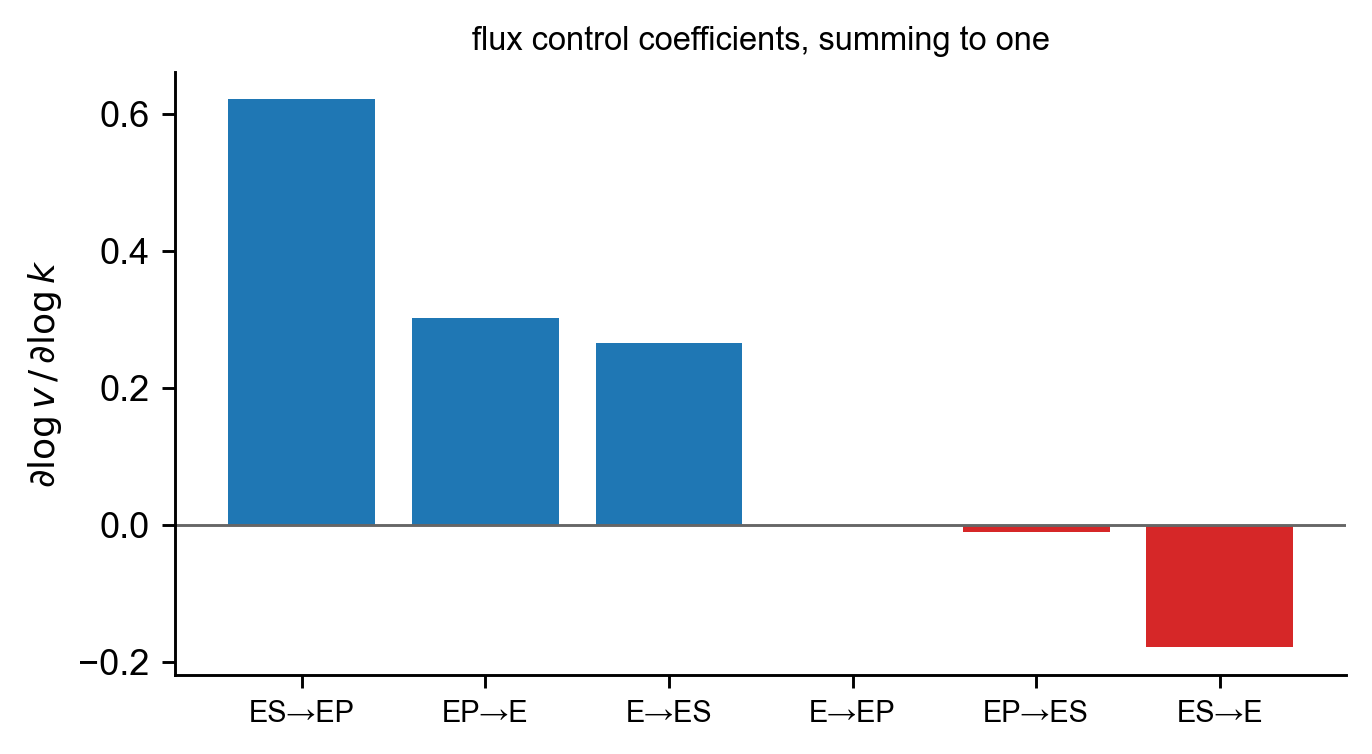

In [24]:
fig, ax = plt.subplots(figsize=(5.4, 3.0))
order = np.argsort(values)[::-1]
colors = ["tab:blue" if values[i] > 0 else "tab:red" for i in order]
ax.bar(range(len(order)), [values[i] for i in order], color=colors)
ax.axhline(0, lw=0.8, color="0.4")
ax.set_xticks(range(len(order)), [labels[i] for i in order], fontsize=8)
ax.set(
    ylabel=r"$\partial \log v\, /\, \partial \log k$",
    title="flux control coefficients, summing to one",
)
ax.title.set_size(9)
fig.tight_layout()
plt.show()

## Reusing this

Everything above came from six rate constants and a topology. The
pattern is: write the mechanism once as a `Scheme`; instantiate it per
condition, folding any concentration into a pseudo-first-order rate
constant; then ask the graph the question the experiment asks.
`equilibrium` and `fluxes` for the steady state, `cycle_affinity` for
whether it is driven and by how much, `absorption_probabilities` for
which of two fates, `mean_first_passage_times` and
`mean_residence_times` for how long and where the time goes,
`passage_rates` or `coarse_grain` for what an instrument that cannot
resolve every state would report,
`propagate` for the transient and `integrate` when a concentration is
still changing, `simulate` and `Trajectory.path` for individual
molecules, `Mutation` for a perturbation expressed in kcal/mol, and
`jax.grad` for which step matters.

[proofreading.ipynb](proofreading.ipynb) takes the same three-state core
and asks what happens when two substrates compete and the enzyme is
driven hard enough to check each one twice.